## Step 1：Upload CSV

In [1]:
from google.colab import files
uploaded = files.upload()

Saving translated.csv to translated.csv


## Step 2：Read and clean basic columns

In [2]:
import pandas as pd

df = pd.read_csv("translated.csv")

# Keep useful columns only
df = df[["id", "message", "translated_message"]]

# Remove empty translated comments
df = df.dropna(subset=["translated_message"])

# Remove duplicated translated comments
df = df.drop_duplicates(subset=["translated_message"])

# Reset index
df = df.reset_index(drop=True)

df.head()

,id,message,translated_message
0,1,Lelaki ini wajib disabitkan atas niat membunuh...,"This man is bound to be declared for murder, a..."
1,2,Lelaki ini wajib disabitkan atas niat membunuh...,"This man is to be declared for murder, and he ..."
2,3,Tak nak letak harapan tinggi dpd pihak berkuas...,"I don't want high hopes for the authorities, b..."
3,4,Kes ustazah outo kena tersilap tekan minyak ni...,Kes ustazah outo has got shined. Press this oi...
4,5,Muka x bersalah langsung â?,"""Lonely guilty face."


## Step 3：Sentiment Labelling using VADER

In [3]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00


In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    return analyzer.polarity_scores(str(text))["compound"]

def get_sentiment_label(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["compound_score"] = df["translated_message"].apply(get_sentiment_score)
df["sentiment_label"] = df["compound_score"].apply(get_sentiment_label)

df.head()

,id,message,translated_message,compound_score,sentiment_label
0,1,Lelaki ini wajib disabitkan atas niat membunuh...,"This man is bound to be declared for murder, a...",-0.2382,Negative
1,2,Lelaki ini wajib disabitkan atas niat membunuh...,"This man is to be declared for murder, and he ...",-0.9062,Negative
2,3,Tak nak letak harapan tinggi dpd pihak berkuas...,"I don't want high hopes for the authorities, b...",0.2899,Positive
3,4,Kes ustazah outo kena tersilap tekan minyak ni...,Kes ustazah outo has got shined. Press this oi...,-0.6486,Negative
4,5,Muka x bersalah langsung â?,"""Lonely guilty face.",-0.6486,Negative


## Step 4：Check label distribution

<Axes: title={'center': 'Sentiment Label Distribution'}, xlabel='sentiment_label'>

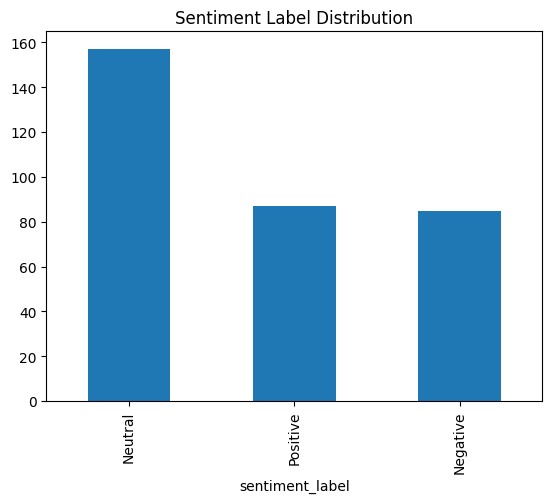

In [5]:
df["sentiment_label"].value_counts().plot(kind="bar", title="Sentiment Label Distribution")

## Step 5：Data Preprocessing using NLTK

In [7]:
import nltk
import re

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

df["cleaned_text"] = df["translated_message"].apply(preprocess_text)

# Fix empty cleaned_text after preprocessing
df["cleaned_text"] = df["cleaned_text"].fillna("")

df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,id,message,translated_message,compound_score,sentiment_label,cleaned_text
0,1,Lelaki ini wajib disabitkan atas niat membunuh...,"This man is bound to be declared for murder, a...",-0.2382,Negative,man bound declared murder there child killer s...
1,2,Lelaki ini wajib disabitkan atas niat membunuh...,"This man is to be declared for murder, and he ...",-0.9062,Negative,man declared murder lost four family johor he ...
2,3,Tak nak letak harapan tinggi dpd pihak berkuas...,"I don't want high hopes for the authorities, b...",0.2899,Positive,dont want high hope authority please let polic...
3,4,Kes ustazah outo kena tersilap tekan minyak ni...,Kes ustazah outo has got shined. Press this oi...,-0.6486,Negative,kes ustazah outo got shined press oil dead pig...
4,5,Muka x bersalah langsung â?,"""Lonely guilty face.",-0.6486,Negative,lonely guilty face


## Step 6：Save final dataset

In [8]:
df.to_csv("sentiment_preprocessed_dataset.csv", index=False)

from google.colab import files
files.download("sentiment_preprocessed_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>